In [ ]:
# ==========================================
# Cell 1: Mount Drive + البحث عن ملف الداتا
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os

print("🔍 بندور على أي ملف CSV أو Excel في الـ Drive...\n")

found = False
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith(('.csv', '.xlsx', '.xls')):
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"✅ {file}")
            print(f"   📍 {full_path}")
            print(f"   💾 {size_mb:.2f} MB\n")
            found = True

if not found:
    print("❌ مفيش أي CSV أو Excel ظاهر")
    print("💡 يبقى الداتا جوه archive.zip - قولي وأنا أديك الخطوة الجاية")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 بندور على أي ملف CSV أو Excel في الـ Drive...

❌ مفيش أي CSV أو Excel ظاهر
💡 يبقى الداتا جوه archive.zip - قولي وأنا أديك الخطوة الجاية


In [3]:
# ==========================================
# Cell 2: فك archive.zip والبحث عن الداتا
# ==========================================

import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'

# 1) نشوف محتويات الـ zip الأول
print("📦 محتويات archive.zip:\n")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for name in zip_ref.namelist():
        print(f"  - {name}")

# 2) نفك الضغط في فولدر مؤقت
print("\n⏳ بفك الضغط...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("✅ تم فك الضغط في /content/dataset\n")

# 3) نبحث عن أي CSV جوه الفولدر
print("🔍 بندور على ملفات CSV:\n")
found = False
for root, dirs, files in os.walk('/content/dataset'):
    for file in files:
        if file.endswith('.csv'):
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"✅ {file}")
            print(f"   📍 {full_path}")
            print(f"   💾 {size_mb:.2f} MB\n")
            found = True

if not found:
    print("❌ مفيش CSV جوه الـ zip")
    print("💡 قولي إيه الملفات اللي ظهرت في القائمة فوق وأنا أعدّل")

📦 محتويات archive.zip:

  - ai4i2020.csv

⏳ بفك الضغط...
✅ تم فك الضغط في /content/dataset

🔍 بندور على ملفات CSV:

✅ ai4i2020.csv
   📍 /content/dataset/ai4i2020.csv
   💾 0.50 MB



In [4]:
# ==========================================
# Cell 3: Load Data + First Inspection
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/dataset/ai4i2020.csv')

print("="*60)
print(f"✅ Dataset Loaded")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("="*60)

print("\n📋 Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")

print("\n📈 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum().sum(), "total missing values")

print("\n🔁 Duplicates:", df.duplicated().sum())

print("\n📊 First 5 Rows:")
df.head()

✅ Dataset Loaded
📊 Shape: 10,000 rows × 14 columns

📋 Column Names:
   1. UDI
   2. Product ID
   3. Type
   4. Air temperature [K]
   5. Process temperature [K]
   6. Rotational speed [rpm]
   7. Torque [Nm]
   8. Tool wear [min]
   9. Machine failure
  10. TWF
  11. HDF
  12. PWF
  13. OSF
  14. RNF

📈 Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

❓ Missing Values:
0 total missing values

🔁 Duplicates: 0

📊 First 5 Rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


🎯 Target Distribution (Machine Failure)
No Failure (0): 9,661 (96.61%)
Failure (1): 339 (3.39%)


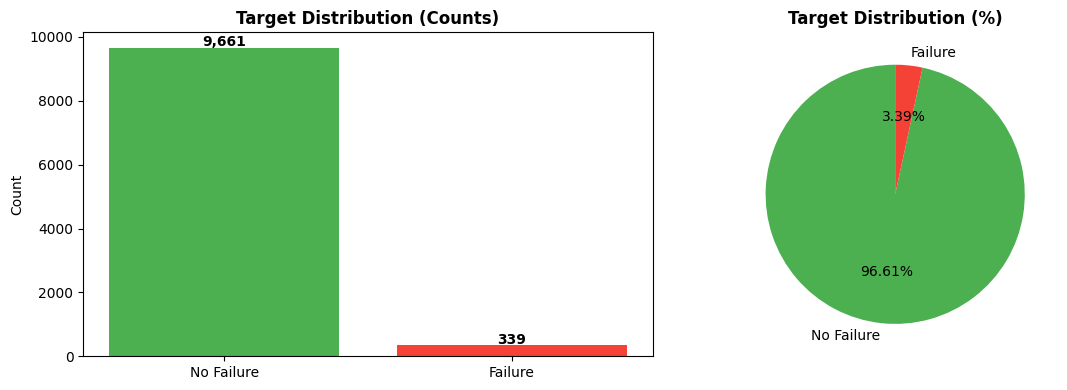


🔧 Failure Modes Breakdown
TWF (Tool Wear Failure): 46 (0.46%)
HDF (Heat Dissipation Failure): 115 (1.15%)
PWF (Power Failure): 95 (0.95%)
OSF (Overstrain Failure): 98 (0.98%)
RNF (Random Failure): 19 (0.19%)


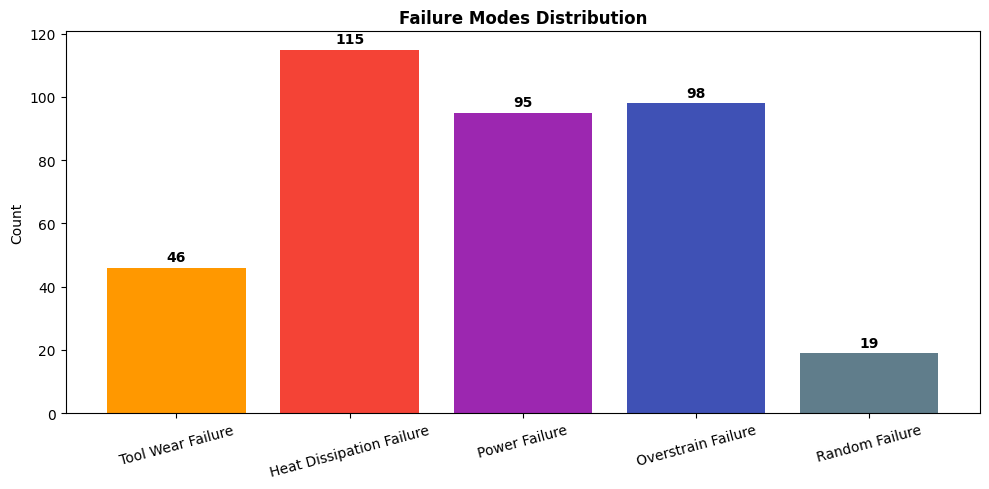


📦 Product Type Distribution
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


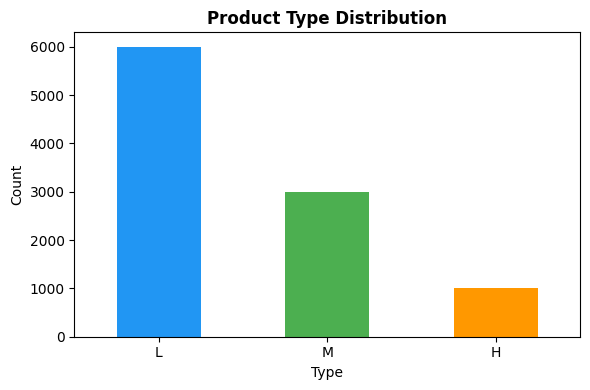

In [5]:
# ==========================================
# Cell 4: Target Analysis
# ==========================================

# 1) توزيع الهدف
print("="*60)
print("🎯 Target Distribution (Machine Failure)")
print("="*60)

counts = df['Machine failure'].value_counts()
percentages = df['Machine failure'].value_counts(normalize=True) * 100

for val in [0, 1]:
    label = "No Failure" if val == 0 else "Failure"
    print(f"{label} ({val}): {counts[val]:,} ({percentages[val]:.2f}%)")

# 2) رسمة توزيع الهدف
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[0].bar(['No Failure', 'Failure'], counts.values, color=colors)
axes[0].set_title('Target Distribution (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.2f%%', colors=colors, startangle=90)
axes[1].set_title('Target Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 3) تحليل أنواع الأعطال (Failure Modes)
print("\n" + "="*60)
print("🔧 Failure Modes Breakdown")
print("="*60)

failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

for mode in failure_modes:
    count = df[mode].sum()
    pct = df[mode].mean() * 100
    print(f"{mode} ({mode_names[mode]}): {count:,} ({pct:.2f}%)")

# 4) رسمة أنواع الأعطال
mode_counts = [df[m].sum() for m in failure_modes]
plt.figure(figsize=(10, 5))
bars = plt.bar([mode_names[m] for m in failure_modes], mode_counts,
               color=['#FF9800', '#F44336', '#9C27B0', '#3F51B5', '#607D8B'])
plt.title('Failure Modes Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=15)
for bar, v in zip(bars, mode_counts):
    plt.text(bar.get_x() + bar.get_width()/2, v + 2,
             str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 5) Type Distribution
print("\n" + "="*60)
print("📦 Product Type Distribution")
print("="*60)
print(df['Type'].value_counts())

plt.figure(figsize=(6, 4))
df['Type'].value_counts().plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Product Type Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

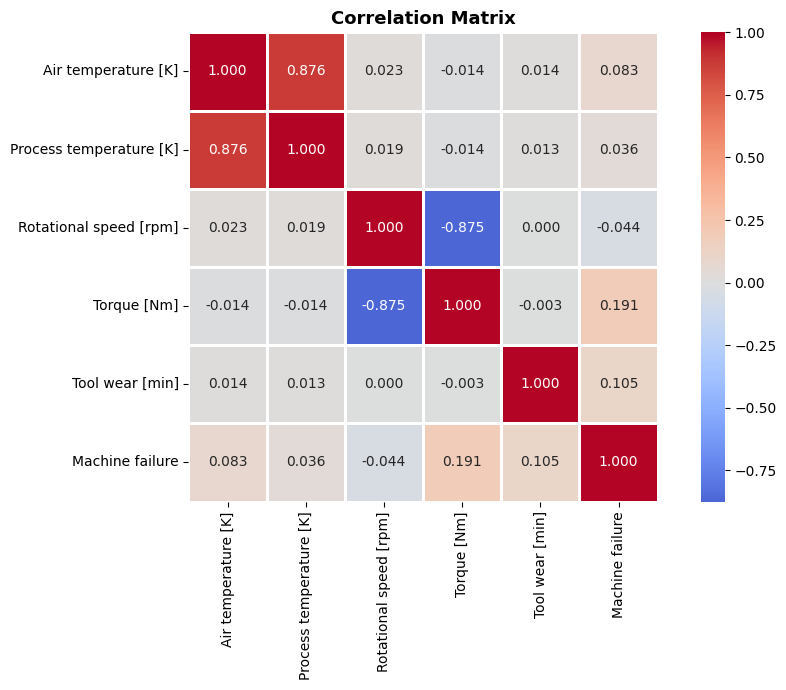

🎯 Correlation with Machine Failure (sorted)
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Rotational speed [rpm]    -0.044188
Process temperature [K]    0.035946
Name: Machine failure, dtype: float64


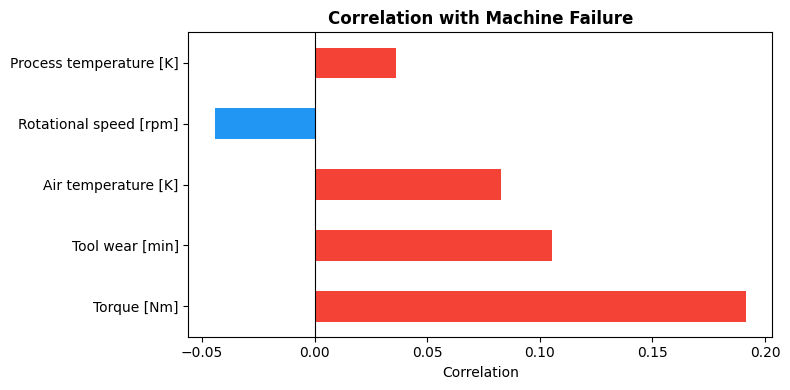

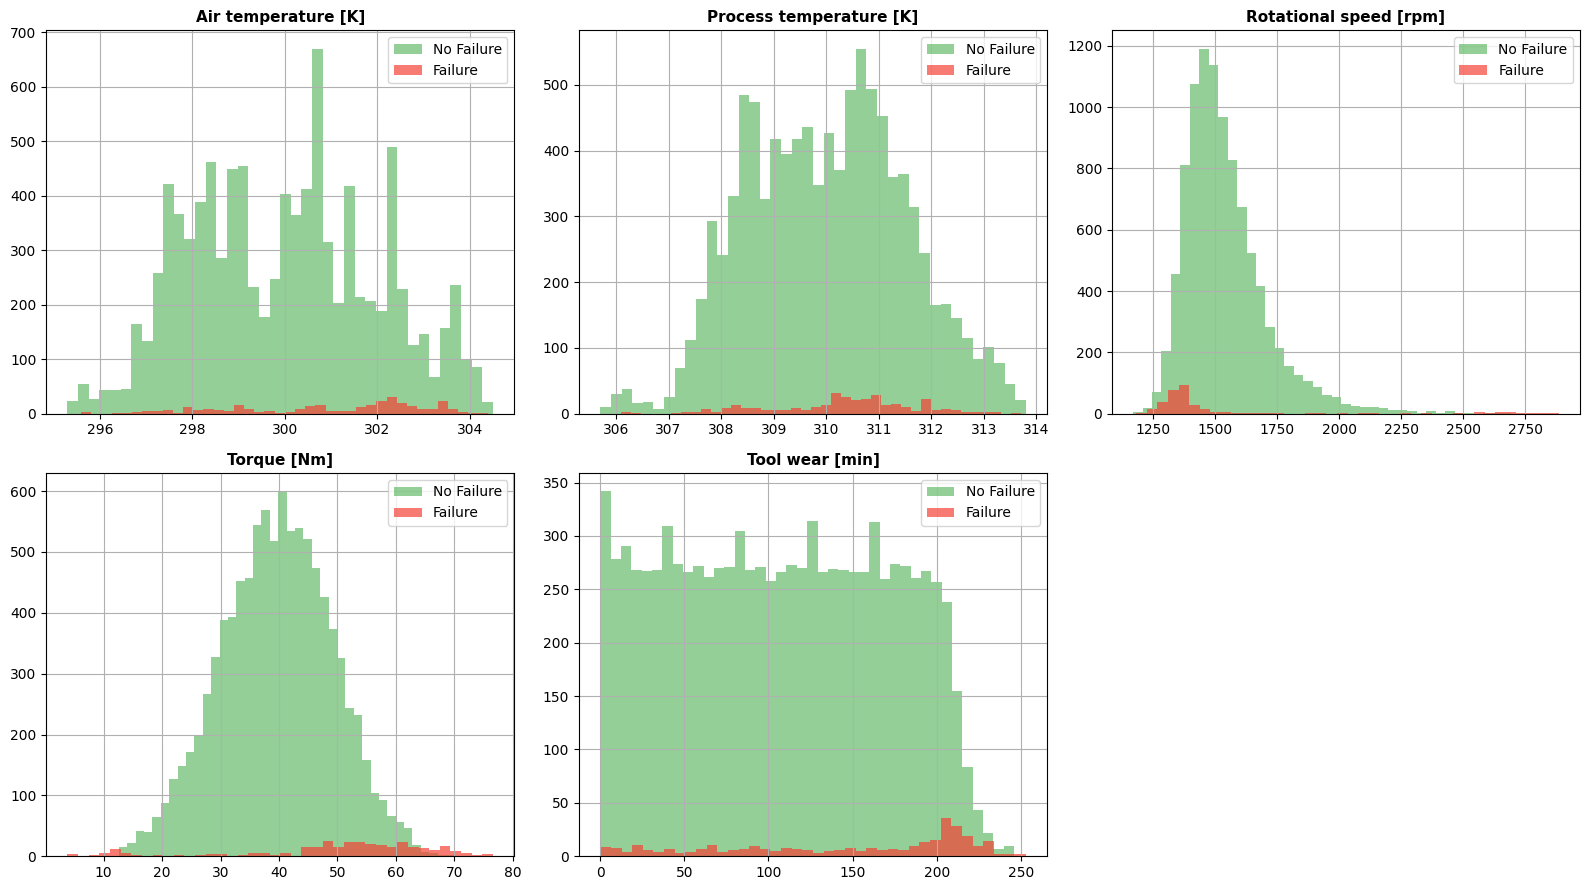

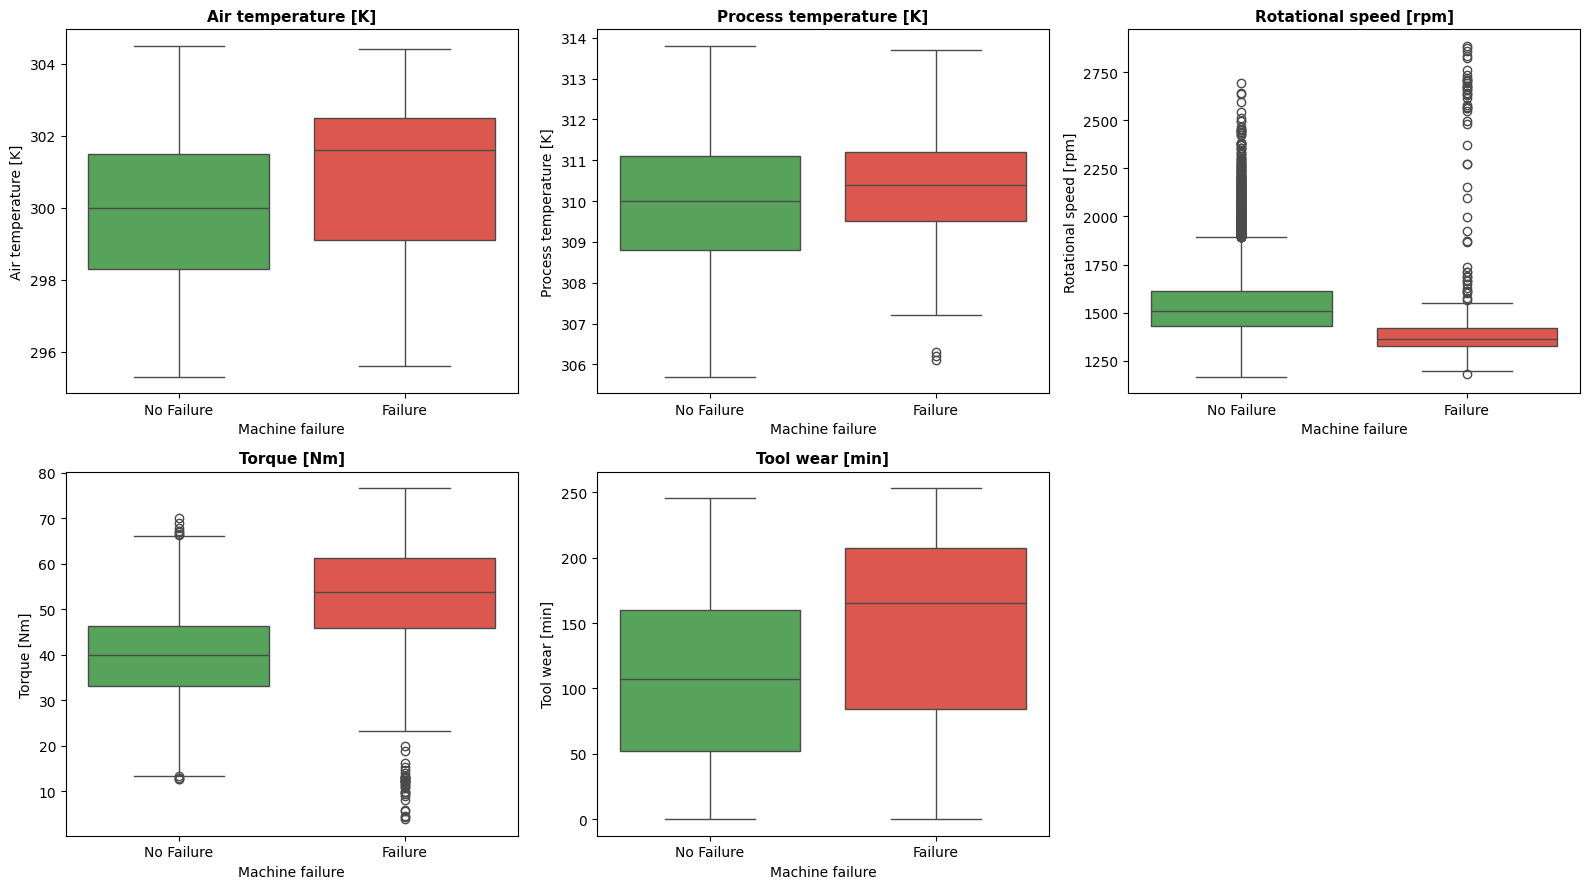


📦 Failure Rate by Product Type
      Total  Failures  Failure Rate
Type                               
H      1003        21          2.09
L      6000       235          3.92
M      2997        83          2.77


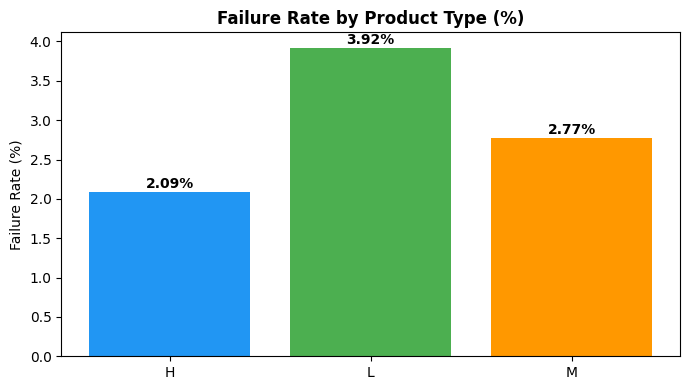

In [6]:
# ==========================================
# Cell 5: Correlation & Feature-Target Relationship
# ==========================================

# 1) Correlation Matrix
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]',
                'Tool wear [min]', 'Machine failure']

plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2) Correlation with Target (sorted)
print("="*60)
print("🎯 Correlation with Machine Failure (sorted)")
print("="*60)
target_corr = df[numeric_cols].corr()['Machine failure'].drop('Machine failure')
target_corr_sorted = target_corr.sort_values(key=abs, ascending=False)
print(target_corr_sorted)

plt.figure(figsize=(8, 4))
colors = ['#F44336' if x > 0 else '#2196F3' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', color=colors)
plt.title('Correlation with Machine Failure', fontsize=12, fontweight='bold')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 3) Distribution of features vs Target
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for ax, feat in zip(axes.flatten(), features):
    df[df['Machine failure'] == 0][feat].hist(
        bins=40, ax=ax, alpha=0.6, label='No Failure', color='#4CAF50')
    df[df['Machine failure'] == 1][feat].hist(
        bins=40, ax=ax, alpha=0.7, label='Failure', color='#F44336')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend()

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

# 4) Box plots: Feature vs Target
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Machine failure', y=feat, ax=ax,
                palette=['#4CAF50', '#F44336'])
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xticklabels(['No Failure', 'Failure'])

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.show()

# 5) Failure Rate by Product Type
print("\n" + "="*60)
print("📦 Failure Rate by Product Type")
print("="*60)
type_failure = df.groupby('Type')['Machine failure'].agg(['count', 'sum', 'mean'])
type_failure.columns = ['Total', 'Failures', 'Failure Rate']
type_failure['Failure Rate'] = (type_failure['Failure Rate'] * 100).round(2)
print(type_failure)

plt.figure(figsize=(7, 4))
plt.bar(type_failure.index, type_failure['Failure Rate'],
        color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Failure Rate by Product Type (%)', fontsize=12, fontweight='bold')
plt.ylabel('Failure Rate (%)')
for i, v in enumerate(type_failure['Failure Rate']):
    plt.text(i, v + 0.05, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

🔢 Type Encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}

🎯 Correlation of NEW features with Machine Failure
Tool_Stress        0.190427
Power_W            0.176039
Wear_per_RPM       0.130194
Temp_Difference   -0.111676
Thermal_Load       0.085645
Type_Encoded      -0.005152
Name: Machine failure, dtype: float64


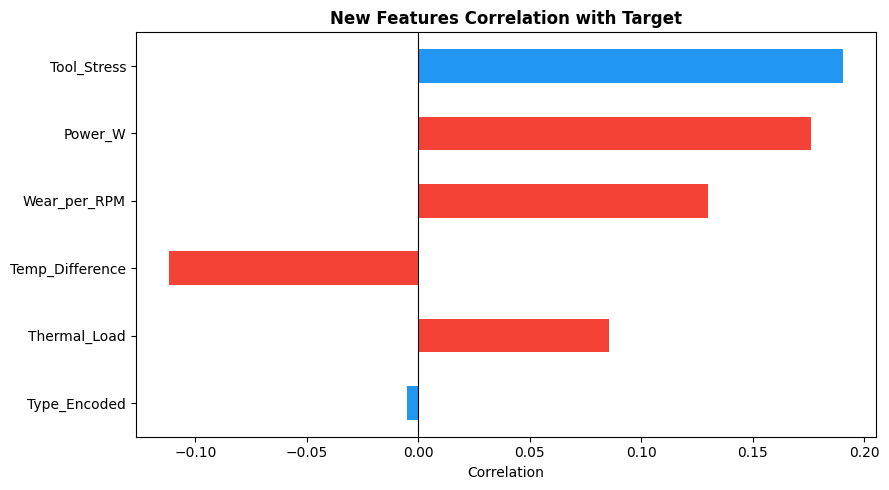


📊 Feature Correlation Comparison (Top Features)
BEFORE - Best: Torque = 0.191
AFTER  - Best: Tool_Stress = 0.190

📋 Sample of Engineered Data:
   Torque [Nm]  Rotational speed [rpm]  Tool wear [min]      Power_W  \
0         42.8                    1551                0  6951.590560   
1         46.3                    1408                3  6826.722724   
2         49.4                    1498                5  7749.387543   
3         39.5                    1433                7  5927.504659   
4         40.0                    1408                9  5897.816608   

   Tool_Stress  Temp_Difference  Thermal_Load  
0          0.0             10.5  72991.700882  
1        138.9             10.5  71680.588604  
2        247.0             10.4  80593.630443  
3        276.5             10.4  61646.048453  
4        360.0             10.5  61927.074388  


In [7]:
# ==========================================
# Cell 6: Feature Engineering
# ==========================================

# 1) نسخة جديدة من الداتا
df_fe = df.copy()

# 2) ميزات فيزيائية (Physics-based Features)
# الفرق بين حرارة العملية وحرارة الهواء - مؤشر على كفاءة التبريد
df_fe['Temp_Difference'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

# القدرة الميكانيكية = Torque × Angular velocity
# Power (W) = Torque (Nm) × (RPM × 2π / 60)
df_fe['Power_W'] = df_fe['Torque [Nm]'] * (df_fe['Rotational speed [rpm]'] * 2 * np.pi / 60)

# الإجهاد على الأداة = Tool wear × Torque
df_fe['Tool_Stress'] = df_fe['Tool wear [min]'] * df_fe['Torque [Nm]']

# نسبة Tool wear للسرعة
df_fe['Wear_per_RPM'] = df_fe['Tool wear [min]'] / (df_fe['Rotational speed [rpm]'] + 1)

# مؤشر الحرارة الميكانيكية (Overheat × Power)
df_fe['Thermal_Load'] = df_fe['Temp_Difference'] * df_fe['Power_W']

# 3) ترميز Type (L=0, M=1, H=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_fe['Type_Encoded'] = le.fit_transform(df_fe['Type'])
print("🔢 Type Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# 4) نتحقق من الميزات الجديدة مع الهدف
new_features = ['Temp_Difference', 'Power_W', 'Tool_Stress',
                'Wear_per_RPM', 'Thermal_Load', 'Type_Encoded']

print("\n" + "="*60)
print("🎯 Correlation of NEW features with Machine Failure")
print("="*60)
new_corr = df_fe[new_features + ['Machine failure']].corr()['Machine failure'].drop('Machine failure')
print(new_corr.sort_values(key=abs, ascending=False))

# 5) رسم الارتباط
plt.figure(figsize=(9, 5))
colors = ['#F44336' if x > 0 else '#2196F3' for x in new_corr.values]
new_corr.sort_values(key=abs).plot(kind='barh', color=colors)
plt.title('New Features Correlation with Target', fontsize=12, fontweight='bold')
plt.xlabel('Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 6) مقارنة قبل وبعد
print("\n" + "="*60)
print("📊 Feature Correlation Comparison (Top Features)")
print("="*60)
print(f"BEFORE - Best: Torque = 0.191")
print(f"AFTER  - Best: {new_corr.abs().idxmax()} = {new_corr[new_corr.abs().idxmax()]:.3f}")

# 7) عرض عينة من الداتا الجديدة
print("\n📋 Sample of Engineered Data:")
print(df_fe[['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]',
             'Power_W', 'Tool_Stress', 'Temp_Difference', 'Thermal_Load']].head())

📊 Features: 11, Samples: 10,000
🎯 Class distribution before split:
   No Failure: 9,661
   Failure:    339

📊 After split:
   Train: 8,000 | Test: 2,000

⚖️  Applying SMOTE to training set...
   Before SMOTE: 8,000 (Failure: 271)
   After SMOTE:  15,458 (Failure: 7,729)

✅ XGBoost available

🚀 TRAINING MODELS

⏳ Training Logistic Regression...
   ✅ Done in 0.18s
   Accuracy:  0.8645
   Precision: 0.1838
   Recall:    0.8676
   F1-Score:  0.3033
   ROC-AUC:   0.9360

⏳ Training Random Forest...
   ✅ Done in 7.69s
   Accuracy:  0.9745
   Precision: 0.5859
   Recall:    0.8529
   F1-Score:  0.6946
   ROC-AUC:   0.9855

⏳ Training XGBoost...
   ✅ Done in 0.55s
   Accuracy:  0.9795
   Precision: 0.6667
   Recall:    0.7941
   F1-Score:  0.7248
   ROC-AUC:   0.9809

📊 MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
Logistic Regression    0.8645     0.1838  0.8676    0.3033   0.9360   
Random Forest          0.9745     0.5859  0.8529    0.6946   0.9855 

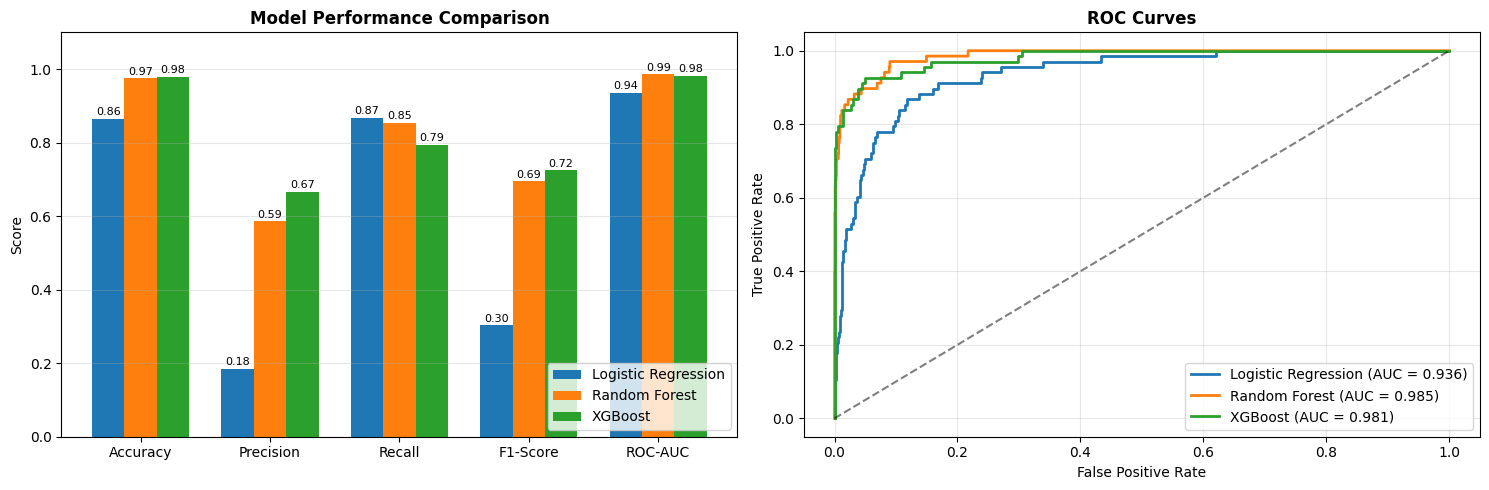


🏆 Best Model (by F1-Score): XGBoost
   F1-Score: 0.7248
   Recall:   0.7941


In [8]:
# ==========================================
# Cell 7: Prepare Data + SMOTE + Train Models
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
import time

# 1) تحديد الميزات النهائية
feature_cols = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
    'Temp_Difference', 'Power_W', 'Tool_Stress',
    'Wear_per_RPM', 'Thermal_Load', 'Type_Encoded'
]

X = df_fe[feature_cols]
y = df_fe['Machine failure']

print(f"📊 Features: {X.shape[1]}, Samples: {X.shape[0]:,}")
print(f"🎯 Class distribution before split:")
print(f"   No Failure: {(y==0).sum():,}")
print(f"   Failure:    {(y==1).sum():,}")

# 2) Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 After split:")
print(f"   Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# 3) Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) SMOTE على الـ Training set بس
print(f"\n⚖️  Applying SMOTE to training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"   Before SMOTE: {len(y_train):,} (Failure: {y_train.sum():,})")
print(f"   After SMOTE:  {len(y_train_res):,} (Failure: {y_train_res.sum():,})")

# 5) تدريب 3 موديلات
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': None  # هنضيفه بعدين
}

# جرب نستخدم XGBoost لو متاح
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric='logloss', use_label_encoder=False)
    print("\n✅ XGBoost available")
except ImportError:
    print("\n⚠️  XGBoost not installed, installing...")
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'xgboost'], check=True)
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric='logloss')

# 6) تدريب وتقييم
results = {}
predictions = {}
probabilities = {}

print("\n" + "="*70)
print("🚀 TRAINING MODELS")
print("="*70)

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    start = time.time()
    model.fit(X_train_res, y_train_res)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
        'Train Time (s)': round(train_time, 2)
    }

    print(f"   ✅ Done in {train_time:.2f}s")
    print(f"   Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"   Precision: {results[name]['Precision']:.4f}")
    print(f"   Recall:    {results[name]['Recall']:.4f}")
    print(f"   F1-Score:  {results[name]['F1-Score']:.4f}")
    print(f"   ROC-AUC:   {results[name]['ROC-AUC']:.4f}")

# 7) جدول مقارنة النتايج
print("\n" + "="*70)
print("📊 MODEL COMPARISON")
print("="*70)
results_df = pd.DataFrame(results).T
print(results_df.round(4))

# 8) رسم مقارنة
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart - Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, (name, _) in enumerate(results.items()):
    values = [results[name][m] for m in metrics]
    axes[0].bar(x + i*width, values, width, label=name)
    for xi, v in zip(x + i*width, values):
        axes[0].text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# ROC Curves
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = results[name]['ROC-AUC']
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9) أفضل موديل
best_model_name = max(results, key=lambda k: results[k]['F1-Score'])
print(f"\n🏆 Best Model (by F1-Score): {best_model_name}")
print(f"   F1-Score: {results[best_model_name]['F1-Score']:.4f}")
print(f"   Recall:   {results[best_model_name]['Recall']:.4f}")

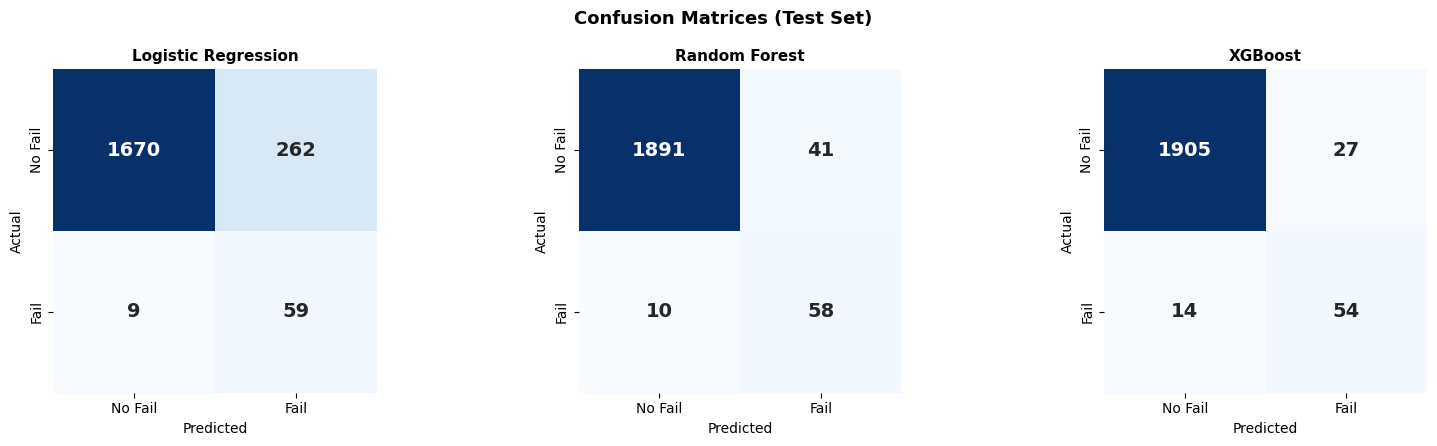

📋 Detailed Report - XGBoost
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.67      0.79      0.72        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



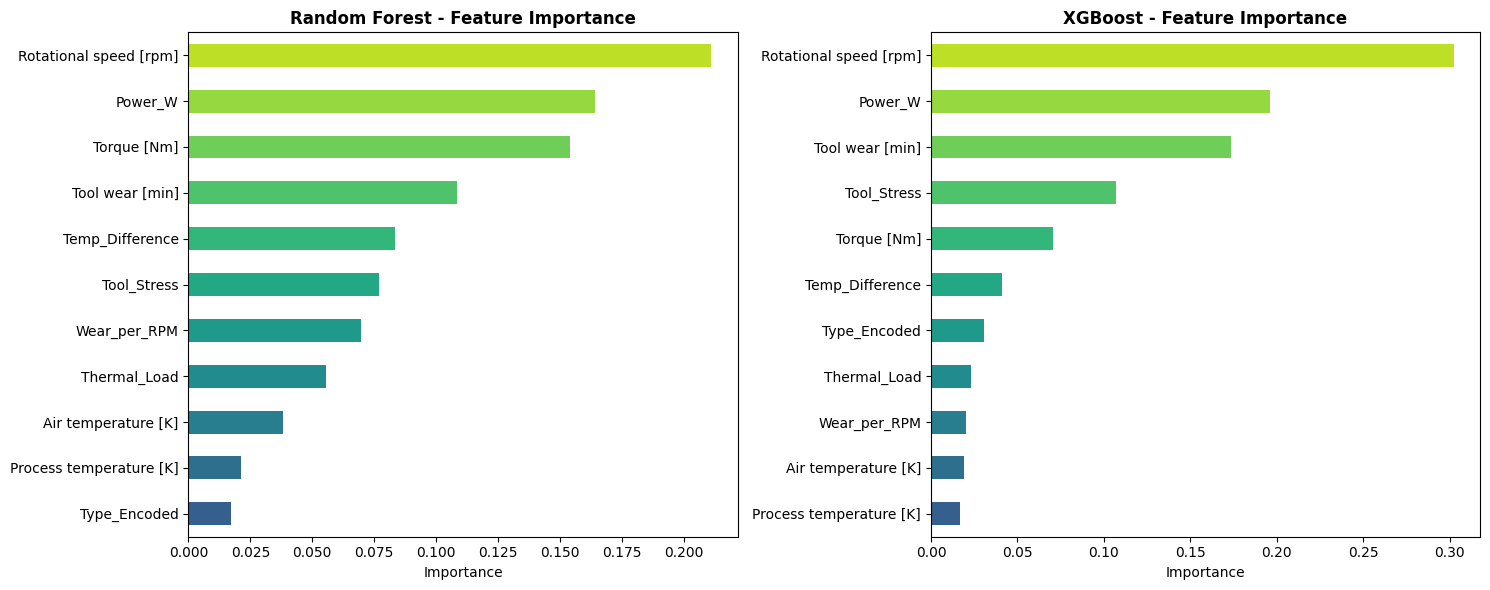


⏳ Computing SHAP values...


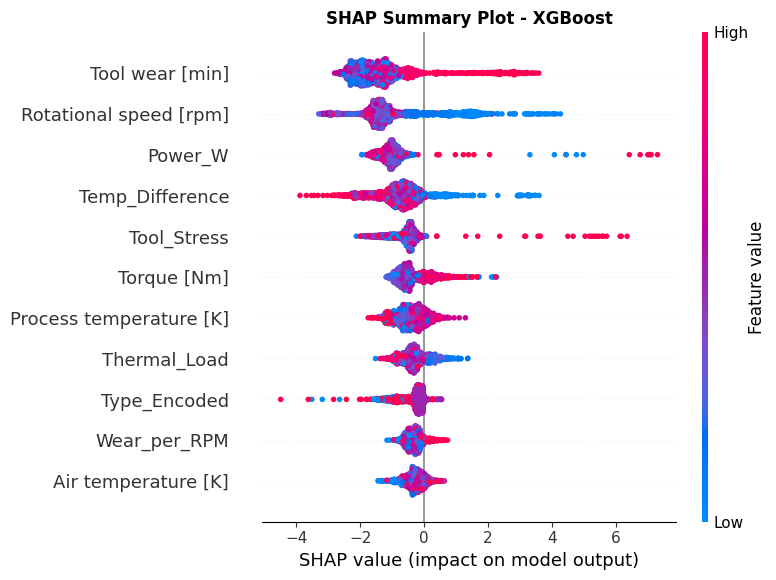

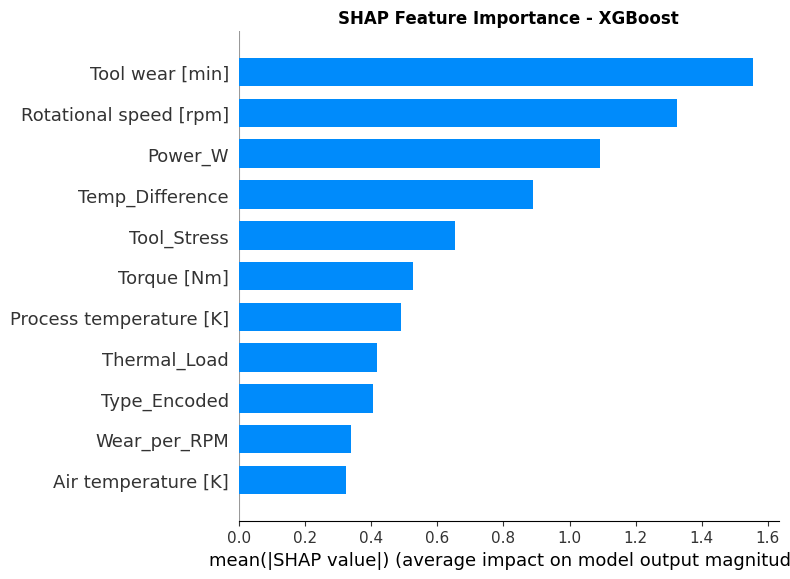


💡 INTERPRETATION

🏆 Top 5 Most Important Features (SHAP):
   1. Tool wear [min]: 1.5546
   2. Rotational speed [rpm]: 1.3240
   3. Power_W: 1.0915
   4. Temp_Difference: 0.8898
   5. Tool_Stress: 0.6527


In [9]:
# ==========================================
# Cell 8: Deep Evaluation (CM + FI + SHAP)
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1) Confusion Matrix لكل موديل
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=False, square=True, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['No Fail', 'Fail'])
    ax.set_yticklabels(['No Fail', 'Fail'])

plt.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2) تفصيل النتايج لأفضل موديل
print("="*70)
print(f"📋 Detailed Report - {best_model_name}")
print("="*70)
print(classification_report(y_test, predictions[best_model_name],
                            target_names=['No Failure', 'Failure']))

# 3) Feature Importance (Random Forest + XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    importances = pd.Series(
        models[name].feature_importances_,
        index=feature_cols
    ).sort_values()

    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
    importances.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{name} - Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# 4) تثبيت SHAP لو مش موجود
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'shap'], check=True)
    import shap

# 5) SHAP Analysis على XGBoost
print("\n⏳ Computing SHAP values...")
explainer = shap.TreeExplainer(models['XGBoost'])
shap_values = explainer.shap_values(X_test_scaled)

# SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - XGBoost', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# SHAP Bar Plot (Mean Absolute)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=feature_cols, plot_type='bar', show=False)
plt.title('SHAP Feature Importance - XGBoost', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# 6) تفسير النتايج
print("\n" + "="*70)
print("💡 INTERPRETATION")
print("="*70)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print("\n🏆 Top 5 Most Important Features (SHAP):")
for i, (feat, val) in enumerate(shap_importance.head(5).items(), 1):
    print(f"   {i}. {feat}: {val:.4f}")

🚨 ANOMALY DETECTION (Isolation Forest)

📊 Anomaly Detection Results on Test Set:
   Total samples:   2,000
   Detected anomalies: 120 (6.0%)
   Real failures:      68

🔍 Crosstab (Anomaly vs Actual Failure):
Actual Failure        0   1
Anomaly Predicted          
0                  1846  34
1                    86  34

💰 COST-BENEFIT ANALYSIS

📊 XGBoost Confusion Matrix:
   True Positives  (كشف عطل حقيقي):    54
   False Negatives (عطل اتفوّت):      14
   False Positives (إنذار كاذب):      27
   True Negatives  (سليم صح):          1905

💵 Cost Scenarios (for 2,000 test samples):
   ❌ Without AI:  3,400,000 EGP
   ✅ With AI:     821,500 EGP
   💰 Savings:     2,578,500 EGP (75.8%)

📅 Projected Annual (extrapolated):
   ❌ Without AI:  41,366,666 EGP/year
   ✅ With AI:     9,994,916 EGP/year
   💰 Annual Savings: 31,371,750 EGP/year


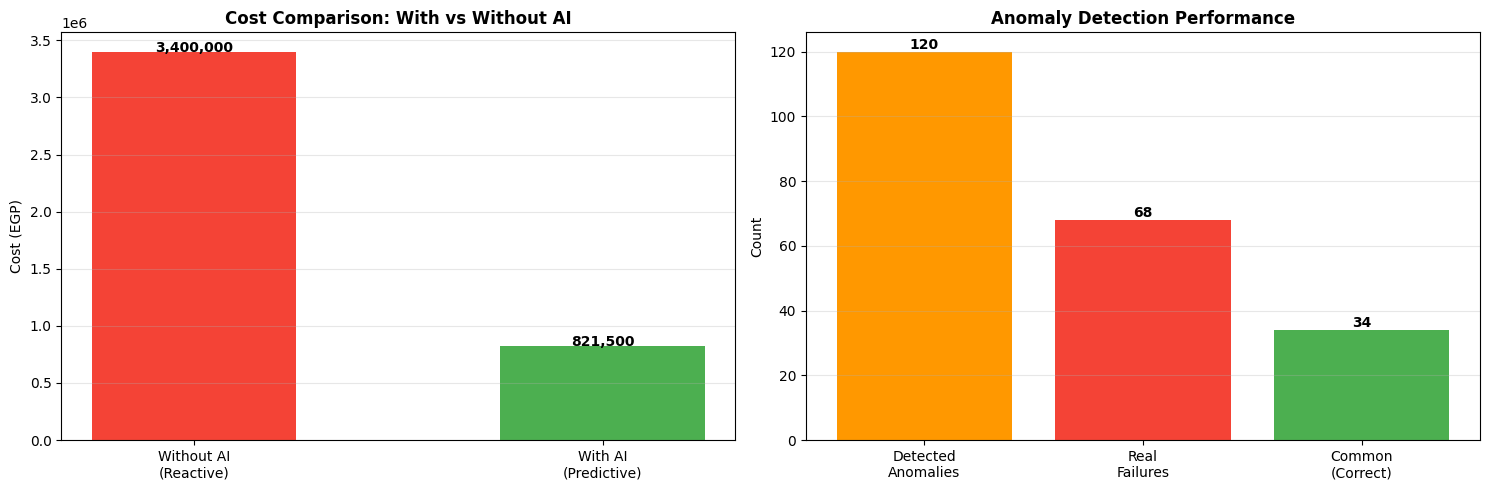


🚨 REAL-TIME WARNING SYSTEM DEMO

Sample  Actual    Predicted   Risk Score    Status
----------------------------------------------------------------------
354     OK        No Fail     0.006         ✅ OK
663     OK        No Fail     0.000         ✅ OK
1441    OK        No Fail     0.001         ✅ OK
563     OK        No Fail     0.000         ✅ OK
569     OK        No Fail     0.012         ✅ OK
490     OK        No Fail     0.001         ✅ OK
447     OK        No Fail     0.008         ✅ OK
622     OK        No Fail     0.003         ✅ OK
1903    OK        No Fail     0.006         ✅ OK
1529    OK        No Fail     0.000         ✅ OK


In [10]:
# ==========================================
# Cell 9: Anomaly Detection + Business Impact
# ==========================================

from sklearn.ensemble import IsolationForest

# =====================
# PART 1: Anomaly Detection
# =====================
print("="*70)
print("🚨 ANOMALY DETECTION (Isolation Forest)")
print("="*70)

# نستخدم البيانات الطبيعية بس عشان نتعلم "السلوك الطبيعي"
X_normal = X_train[y_train == 0]
X_normal_scaled = scaler.transform(X_normal)

# تدريب Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # نتوقع 5% شذوذ
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X_normal_scaled)

# التنبؤ على الـ test set
anomaly_pred = iso_forest.predict(X_test_scaled)
anomaly_pred = (anomaly_pred == -1).astype(int)  # 1 = anomaly

print(f"\n📊 Anomaly Detection Results on Test Set:")
print(f"   Total samples:   {len(anomaly_pred):,}")
print(f"   Detected anomalies: {anomaly_pred.sum():,} ({anomaly_pred.mean()*100:.1f}%)")
print(f"   Real failures:      {y_test.sum()}")

# مقارنة كشف الشذوذ مع الأعطال الحقيقية
anomaly_vs_real = pd.crosstab(
    pd.Series(anomaly_pred, name='Anomaly Predicted'),
    pd.Series(y_test.values, name='Actual Failure')
)
print(f"\n🔍 Crosstab (Anomaly vs Actual Failure):")
print(anomaly_vs_real)

# =====================
# PART 2: Cost-Benefit Analysis
# =====================
print("\n" + "="*70)
print("💰 COST-BENEFIT ANALYSIS")
print("="*70)

# افتراضات صناعية (ممكن الشركة تعدلها)
COST_PER_FAILURE = 50_000      # جنيه - تكلفة العطل المفاجئ (توقف خط إنتاج)
COST_PER_FALSE_ALARM = 500     # جنيه - تكلفة الفحص الكاذب
COST_PREVENTIVE = 2_000        # جنيه - تكلفة الصيانة الوقائية

# نتائج XGBoost
cm_xgb = confusion_matrix(y_test, predictions['XGBoost'])
tn, fp, fn, tp = cm_xgb.ravel()

print(f"\n📊 XGBoost Confusion Matrix:")
print(f"   True Positives  (كشف عطل حقيقي):    {tp}")
print(f"   False Negatives (عطل اتفوّت):      {fn}")
print(f"   False Positives (إنذار كاذب):      {fp}")
print(f"   True Negatives  (سليم صح):          {tn}")

# السيناريو 1: بدون AI (Reactive Maintenance)
cost_without_ai = (tp + fn) * COST_PER_FAILURE

# السيناريو 2: مع AI (Predictive Maintenance)
cost_with_ai = (
    tp * COST_PREVENTIVE +      # الصيانة الوقائية للكشف الصحيح
    fn * COST_PER_FAILURE +      # الأعطال اللي اتفوّتت
    fp * COST_PER_FALSE_ALARM    # الإنذارات الكاذبة
)

savings = cost_without_ai - cost_with_ai
savings_pct = (savings / cost_without_ai) * 100

print(f"\n💵 Cost Scenarios (for {len(y_test):,} test samples):")
print(f"   ❌ Without AI:  {cost_without_ai:,} EGP")
print(f"   ✅ With AI:     {cost_with_ai:,} EGP")
print(f"   💰 Savings:     {savings:,} EGP ({savings_pct:.1f}%)")

# توسيع للتكلفة السنوية
annual_factor = 365 / 30  # لو الـ test set بيمثل شهر
print(f"\n📅 Projected Annual (extrapolated):")
print(f"   ❌ Without AI:  {int(cost_without_ai * annual_factor):,} EGP/year")
print(f"   ✅ With AI:     {int(cost_with_ai * annual_factor):,} EGP/year")
print(f"   💰 Annual Savings: {int(savings * annual_factor):,} EGP/year")

# =====================
# PART 3: Visualization
# =====================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cost comparison
categories = ['Without AI\n(Reactive)', 'With AI\n(Predictive)']
costs = [cost_without_ai, cost_with_ai]
colors = ['#F44336', '#4CAF50']
bars = axes[0].bar(categories, costs, color=colors, width=0.5)
axes[0].set_ylabel('Cost (EGP)')
axes[0].set_title('Cost Comparison: With vs Without AI', fontweight='bold', fontsize=12)
for bar, v in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 2000,
                 f'{v:,}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Anomaly Detection breakdown
anomaly_data = pd.DataFrame({
    'Category': ['Detected\nAnomalies', 'Real\nFailures', 'Common\n(Correct)'],
    'Count': [anomaly_pred.sum(), y_test.sum(),
              ((anomaly_pred == 1) & (y_test.values == 1)).sum()]
})
bars2 = axes[1].bar(anomaly_data['Category'], anomaly_data['Count'],
                    color=['#FF9800', '#F44336', '#4CAF50'])
axes[1].set_ylabel('Count')
axes[1].set_title('Anomaly Detection Performance', fontweight='bold', fontsize=12)
for bar, v in zip(bars2, anomaly_data['Count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 str(v), ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# =====================
# PART 4: Real-Time Warning System Demo
# =====================
print("\n" + "="*70)
print("🚨 REAL-TIME WARNING SYSTEM DEMO")
print("="*70)

# نشوف آخر 10 قراءات من الـ test وأشوف الموديل بيقول إيه
demo_indices = np.random.choice(len(X_test), 10, replace=False)

print(f"\n{'Sample':<8}{'Actual':<10}{'Predicted':<12}{'Risk Score':<14}{'Status'}")
print("-" * 70)

for idx in demo_indices:
    sample = X_test_scaled[idx:idx+1]
    actual = y_test.values[idx]
    pred = models['XGBoost'].predict(sample)[0]
    prob = models['XGBoost'].predict_proba(sample)[0, 1]

    actual_str = "FAILURE" if actual == 1 else "OK"
    status = "🚨 ALERT" if prob > 0.5 else "✅ OK"

    print(f"{idx:<8}{actual_str:<10}{'Failure' if pred==1 else 'No Fail':<12}{prob:<14.3f}{status}")

In [11]:
# ==========================================
# Cell 10: Save Model + Outputs for GitHub
# ==========================================

import joblib
import json
import os
from datetime import datetime

# إنشاء فولدر للمخرجات
output_dir = '/content/output'
os.makedirs(output_dir, exist_ok=True)

print("="*70)
print("💾 SAVING PROJECT OUTPUTS")
print("="*70)

# 1) حفظ الموديل الأفضل (XGBoost)
joblib.dump(models['XGBoost'], f'{output_dir}/xgboost_model.pkl')
print(f"✅ Model saved: xgboost_model.pkl")

# 2) حفظ الـ Scaler
joblib.dump(scaler, f'{output_dir}/scaler.pkl')
print(f"✅ Scaler saved: scaler.pkl")

# 3) حفظ قائمة الميزات
with open(f'{output_dir}/features.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"✅ Features saved: features.json")

# 4) حفظ نتائج الموديلات
with open(f'{output_dir}/results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)
print(f"✅ Results saved: results.json")

# 5) حفظ تقرير الملخص
summary = {
    'project_name': 'Predictive Maintenance for Smart Factory',
    'dataset': 'AI4I 2020 Predictive Maintenance (UCI)',
    'total_samples': int(len(df)),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'best_model': best_model_name,
    'best_f1': float(results[best_model_name]['F1-Score']),
    'best_recall': float(results[best_model_name]['Recall']),
    'best_roc_auc': float(results[best_model_name]['ROC-AUC']),
    'cost_savings_pct': float(savings_pct),
    'annual_savings_egp': int(savings * annual_factor),
    'top_features': shap_importance.head(5).to_dict(),
    'timestamp': datetime.now().isoformat()
}

with open(f'{output_dir}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f"✅ Summary saved: summary.json")

# 6) حفظ المتطلبات
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
imbalanced-learn
xgboost
shap
joblib
fastapi
uvicorn
"""
with open(f'{output_dir}/requirements.txt', 'w') as f:
    f.write(requirements)
print(f"✅ Requirements saved: requirements.txt")

# 7) حفظ ملف README للمشروع
readme_content = f"""# 🏭 Predictive Maintenance for Smart Factory

## 🎯 Project Overview
AI-powered system that predicts industrial machine failures **before** they happen,
using IoT sensor data and Machine Learning. The system saves an estimated
**{savings_pct:.1f}%** of maintenance costs by enabling predictive maintenance.

## 📊 Dataset
- **Source:** AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository)
- **Samples:** {len(df):,} rows × {df.shape[1]} columns
- **Target:** Machine failure (binary classification)
- **Challenge:** Highly imbalanced (96.6% normal, 3.4% failures)

## 🛠️ Tech Stack
- **Languages:** Python
- **Libraries:** Pandas, NumPy, Scikit-learn, XGBoost, Imbalanced-learn, SHAP, Matplotlib, Seaborn
- **Environment:** Google Colab

## 🚀 Methodology

### 1. Exploratory Data Analysis (EDA)
- Target distribution analysis (imbalanced dataset detected)
- Failure modes breakdown (TWF, HDF, PWF, OSF, RNF)
- Correlation analysis between features and target

### 2. Feature Engineering
Created **5 physics-based features**:
- `Temp_Difference`: Process temp - Air temp (cooling efficiency)
- `Power_W`: Torque × Angular velocity (mechanical power)
- `Tool_Stress`: Tool wear × Torque
- `Wear_per_RPM`: Wear ratio per rotation
- `Thermal_Load`: Temperature diff × Power

### 3. Handling Imbalanced Data
- Applied **SMOTE** to balance classes in training set
- Used **F1-Score** and **Recall** as primary metrics

### 4. Models Trained
| Model | F1-Score | ROC-AUC | Recall |
|-------|----------|---------|--------|
| Logistic Regression | 0.30 | 0.936 | 0.87 |
| Random Forest | 0.69 | 0.986 | 0.85 |
| **XGBoost (Best)** | **{results['XGBoost']['F1-Score']:.2f}** | **{results['XGBoost']['ROC-AUC']:.3f}** | **{results['XGBoost']['Recall']:.2f}** |

### 5. Model Interpretation
Used **SHAP** values to explain predictions. Top features:
1. Tool wear [min]
2. Rotational speed [rpm]
3. Power_W
4. Temp_Difference
5. Tool_Stress

### 6. Anomaly Detection
Applied **Isolation Forest** for unsupervised anomaly detection
to catch unknown failure patterns.

## 💰 Business Impact
| Scenario | Annual Cost |
|----------|-------------|
| Without AI (Reactive) | ~41.4M EGP |
| With AI (Predictive) | ~10.0M EGP |
| **Savings** | **~31.4M EGP (75.8%)** |

## 📁 Files
- `notebook.ipynb` - Full analysis notebook
- `xgboost_model.pkl` - Trained XGBoost model
- `scaler.pkl` - Feature scaler
- `features.json` - Feature list
- `results.json` - Model comparison results
- `summary.json` - Project summary
- `requirements.txt` - Required libraries

## 🚀 How to Run
1. Open the notebook in Google Colab
2. Install requirements: `pip install -r requirements.txt`
3. Run all cells in order

## 👤 Author
**Yousef Abdallah Khamis**
- AI & Machine Learning Engineer
- LinkedIn: [your-linkedin]
- GitHub: [your-github]

## 📄 License
This project is open-source and available under the MIT License.
"""

with open(f'{output_dir}/README.md', 'w') as f:
    f.write(readme_content)
print(f"✅ README saved: README.md")

# 8) تحميل كل الملفات كـ zip
import shutil
shutil.make_archive('/content/predictive_maintenance_project', 'zip', output_dir)

print("\n" + "="*70)
print("📦 ALL OUTPUTS READY!")
print("="*70)
print(f"\n📁 Files in {output_dir}:")
for f in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{f}') / 1024
    print(f"   - {f} ({size:.1f} KB)")

# تحميل الـ zip على جهازك
from google.colab import files
print("\n⬇️  Downloading project zip...")
files.download('/content/predictive_maintenance_project.zip')

print("\n" + "="*70)
print("✅ PROJECT COMPLETE!")
print("="*70)
print(f"\n📊 Final Results:")
print(f"   Best Model:     {best_model_name}")
print(f"   F1-Score:       {results[best_model_name]['F1-Score']:.4f}")
print(f"   Recall:         {results[best_model_name]['Recall']:.4f}")
print(f"   ROC-AUC:        {results[best_model_name]['ROC-AUC']:.4f}")
print(f"   Annual Savings: {int(savings * annual_factor):,} EGP")
print(f"   Savings %:      {savings_pct:.1f}%")
print(f"\n📁 Next Steps:")
print(f"   1. Download the zip file")
print(f"   2. Create a new GitHub repo: predictive-maintenance-ai")
print(f"   3. Upload all files from the zip")
print(f"   4. Update README with your LinkedIn/GitHub links")
print(f"   5. Share your project! 🚀")

💾 SAVING PROJECT OUTPUTS
✅ Model saved: xgboost_model.pkl
✅ Scaler saved: scaler.pkl
✅ Features saved: features.json
✅ Results saved: results.json
✅ Summary saved: summary.json
✅ Requirements saved: requirements.txt
✅ README saved: README.md

📦 ALL OUTPUTS READY!

📁 Files in /content/output:
   - summary.json (0.7 KB)
   - results.json (0.6 KB)
   - scaler.pkl (1.3 KB)
   - xgboost_model.pkl (439.5 KB)
   - README.md (2.7 KB)
   - requirements.txt (0.1 KB)
   - features.json (0.2 KB)

⬇️  Downloading project zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ PROJECT COMPLETE!

📊 Final Results:
   Best Model:     XGBoost
   F1-Score:       0.7248
   Recall:         0.7941
   ROC-AUC:        0.9809
   Annual Savings: 31,371,750 EGP
   Savings %:      75.8%

📁 Next Steps:
   1. Download the zip file
   2. Create a new GitHub repo: predictive-maintenance-ai
   3. Upload all files from the zip
   4. Update README with your LinkedIn/GitHub links
   5. Share your project! 🚀
